# kNN and Performance Measures


### kNN Recap

In the K-Nearest Neighbors algorithm, in order to classify a point, we measure the distance (e.g. Euclidean distance) to the nearest k instances of the training set, and let them vote. K is typically chosen to be an odd number.

![KNN](https://miro.medium.com/max/1300/0*Sk18h9op6uK9EpT8.)


### Example
We illustrate kNN with a simple synthetic data set.

In [1]:
# Import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from Exercise02.Exercise2_SOLUTION import y_pred

# Customize plots
%matplotlib inline
sns.set_theme(style="white")
plt.style.use('grayscale')

# Supress warnings
import warnings
warnings.filterwarnings('ignore')

The code below generates 16 points in the plane [0,1]. Points with low values of x1 and x2 are associated with class 0 and points with high values of x1 and x2 are associated with class 1.

In [2]:
# Create Data
data = {"x1":[0, 0.4, 0.15, 0.05, 0.4, 0.20, 0, 0.45, 1, 0.85, 0.9, 0.7, 0.65, 0.95, 1, 0.8],
"x2":[0.2, 0.35, 0, 0.10, 0.4, 0.25, 0.40, 0.35, 0.85, 0.95, 1, 0.65, 0.75, 0.9, 0.9, 0.95],
"y":[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]}

data = pd.DataFrame(data)
data

,x1,x2,y
0,0.00,0.20,0
1,0.40,0.35,0
2,0.15,0.00,0
3,0.05,0.10,0
4,0.40,0.40,0
5,0.20,0.25,0
6,0.00,0.40,0
7,0.45,0.35,0
8,1.00,0.85,1
9,0.85,0.95,1


We also have 3 new points for which we do not know the class.

We want to build a model to find out to which class (0 or 1) these 3 point belong to.

In [3]:
# New points
p = pd.DataFrame({"name":["p1", "p2", "p3"], "x1":[0.15, 0.75, 0.5],
"x2":[0.35, 0.8, 0.6]})
p

,name,x1,x2
0,p1,0.15,0.35
1,p2,0.75,0.80
2,p3,0.50,0.60


First we plot our dataset with the x1 values on the horizontal axis and the x2 values on the vertical axes. We color points according to the y target variable, which only takes values 0 (red) and 1 (blue).

The new points are marked by an orange x marker.

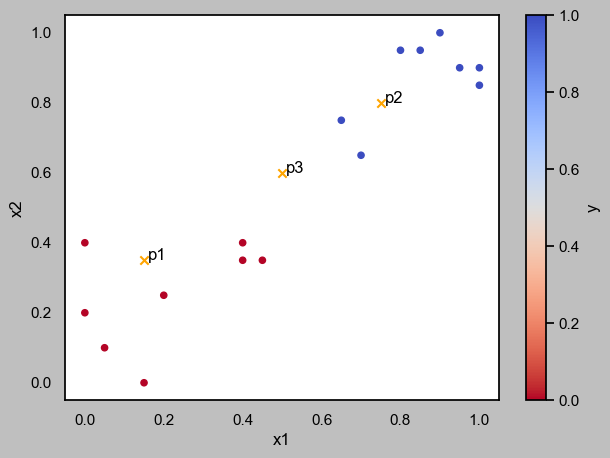

In [4]:
# Plot
data.plot.scatter("x1", "x2", c="y", colormap="coolwarm_r", figsize=(7, 5))
plt.scatter(p.x1, p.x2, c="orange", marker="x")
for point in p.values:
  plt.text(point[1]+0.01, point[2], point[0])

The two classes can be identified on the above scatter plot. In addition, p1 seems to belong to class 0, p2 to class 1. The class assignment for p3 is not so clear. 

Below we classify the new points using the kNN algorithm with different k (i.e. the number of neighboors we consider for the class voting when assigning a class). 

In [5]:
# Select X and y
X = data[["x1", "x2"]]
y = data["y"]

First build a simple model using the sklearn `KNeighborsClassifier`.

In [6]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X, y)
y_pred = knn.predict(X)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1])

Let's have a look at what parameters it used by default. We can check their meaning by looking the the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html).

* How many neighbors? `n_neighbors` this is the number of neighbors to use. The default is 5.  
* What similarity/distance measure to use? `p` set p=2  to use the Euclidean distance (L2) and p = 1 to use the Manhattan distance (l1)
* What weight to give to the different neighbors? `weights` use uniform if all points should be given equal weight, use distance if you want to weigh neighbors by the inverse of their distance.

In [7]:
knn

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


But let's now see what class kNN would predict for our 3 points with unknown labels for different values of k.

In [ ]:
# KNN plot
fig, ax = plt.subplots(1, 3, figsize=(18,5))
i = 0
for k in [1, 3, 5]:
  model = KNeighborsClassifier(n_neighbors=k).fit(X,y)
  pred = model.predict(p[["x1", "x2"]])
  ax[i].scatter(data.x1, data.x2, c=data.y, cmap="coolwarm_r")
  ax[i].scatter(p.x1, p.x2, c=pred, cmap="coolwarm_r", marker="x")
  ax[i].set_title("KNN with k = " + str(k))
  i += 1

For k = 1 and k = 3, p3 belongs to class 0 while it belongs to class 1 for k = 5.

## Exercise: Diabetes Classification

We will work on the diabetes dataset that contains patient attributes (e.g. age, glucose, ...) and information on whether the patient is diagnosed with diabetes (0 meaning "no", 1 meaning "yes"). The goal is to learn a model that predicts whether a (new) patient has diabetes given based on their individual characteristics (the set of patient attributes). This is a classification task and you can use the kNN classifier.

#### 1. Load and prepare the data for learning
Get the inputs X and targets y from the dataset. Always leave a poriton of the data for testing. The test dataset should not be used for model development or model selection but should be kept for the performance assessment of the final model. We split the data-set into 80% training and 20% test examples to create the training set and test set. For the kNN classifier when the input features are in different ranges the data also needs to be scaled and we use the StandardSCaler from sklearn to do this.

In [ ]:
# Import additional libraries
# data splitting
from sklearn.model_selection import train_test_split
# data scaling
from sklearn.preprocessing import StandardScaler
# performance measures
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix,f1_score,precision_score,recall_score,accuracy_score,average_precision_score
# classifier
from sklearn.neighbors import KNeighborsClassifier
# set a random seed
np.random.seed(1)

df = pd.read_csv('DiabetesDataset.csv')
print(df.info)
# keep the patient characteristics as inputs x and the diabetes as target y
x = df.drop(columns=['Diabetes'])
y = df['Diabetes'].values
labels = ["No Diabetes", "Diabetes"]

# check out the ranges and distributions of the different input features using boxplots
plt.figure(figsize=(15,7))
sns.boxplot(data=x)
plt.xticks(rotation=90)
plt.show()

# Split data into training and test dataset
trainX, testX, trainy, testy = train_test_split(x, y, test_size=0.2)

# Scale the dataset using StandardScaler
scaler = StandardScaler()
trainX = scaler.fit_transform(trainX)
testX = scaler.transform(testX)

#### 2. Model fitting and performance evaluation
Use a k-NN classifier with k = 5 on the training set created previously. Calculate accuracy, recall, precision and f1-score for your classifier and plot the confusion matrix 
to analyze the performance of the model.

Accuracy: 0.80, Recall: 0.60, Precision: 0.79, F1-score: 0.68


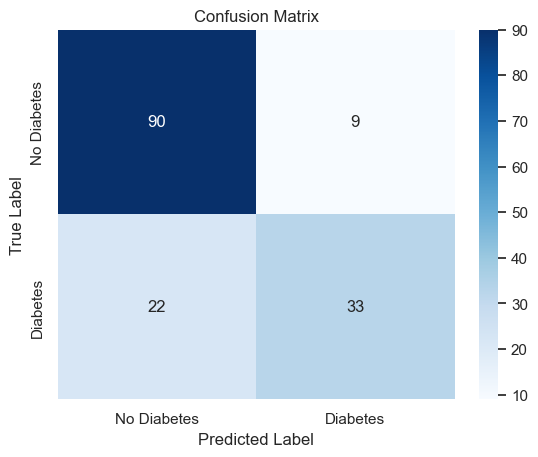

In [19]:
#### START YOUR SOLUTION HERE ####
# Fit kNN model with k=5 to the training data
model = KNeighborsClassifier(n_neighbors=5)
model.fit(trainX, trainy)

# Get predictions on test set
y_pred = knn.predict(testX)

# Compute the performance measures listed in the text above
accuracy, recall, precision, f1 = accuracy_score(testy, y_pred), \
    recall_score(testy, y_pred), \
    precision_score(testy, y_pred), \
    f1_score(testy, y_pred)

# Print the values of all performance measures except the confusion matrix 
print(f"Accuracy: {accuracy:.2f}, Recall: {recall:.2f}, Precision: {precision:.2f}, F1-score: {f1:.2f}")

# Display confusion matrix using a heatmap
sns.heatmap(confusion_matrix(testy, y_pred), annot=True, xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### END YOUR SOLUTION HERE ####


#### 2. Performance Curves
Compute the values necessary for plotting the area under the ROC and Precision-Recall curves and then plot and inspect the curves.

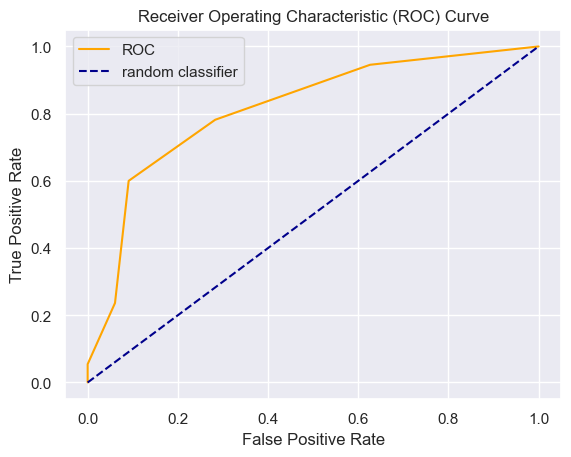

ROC AUC: 0.81


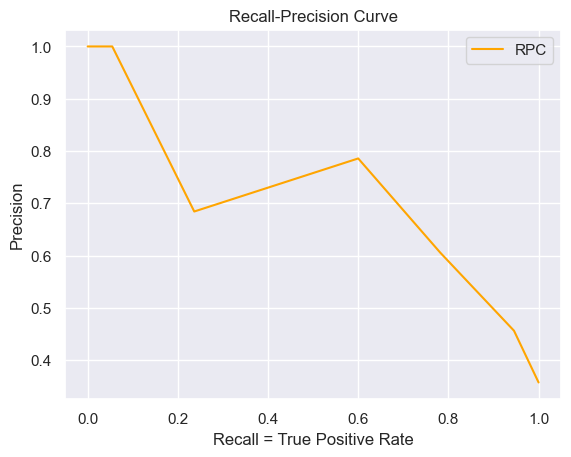

RPC AUC: 0.67


In [14]:
# Predict probabilities for the test set
probs = model.predict_proba(testX)

# Keep the Probabilities of the positive class only
probs = probs[:, 1]

# Function for plotting the ROC curve
def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--', label = 'random classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

# Function for plotting the Precision-Recall curve
def plot_rpc(recall, precision):
    plt.plot(recall, precision, color='orange', label='RPC')
    plt.ylabel('Precision')
    plt.xlabel('Recall = True Positive Rate')
    plt.title('Recall-Precision Curve')
    plt.legend()
    plt.show()


#### START YOUR SOLUTION HERE ####
# Compute and plot ROC curve (check out the function roc_curve)
fpr, tpr, thresholds = roc_curve(testy, probs)
plot_roc_curve(fpr, tpr)

# Compute the Area Under the ROC Curve (AUC) - the ROC AUC score
roc_auc = roc_auc_score(testy, probs)
print(f"ROC AUC: {roc_auc:.2f}")

# Plot Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(testy, probs)
plot_rpc(recall, precision)

# Compute average precision - Precision-Recall AUC
rpc_auc = average_precision_score(testy, probs)
print(f"RPC AUC: {rpc_auc:.2f}")

#### END YOUR SOLUTION HERE ####

#### 3. Assignment: Different Values of k
Now fit two additional k-NN classifies to the same dataset with `k` values 1 and n (number of training samples), respectively. Compute the accuracies and plot the corresponding confusion matrix to analyze the prediction results for each model.

614
Accuracy for k = 1: 0.69


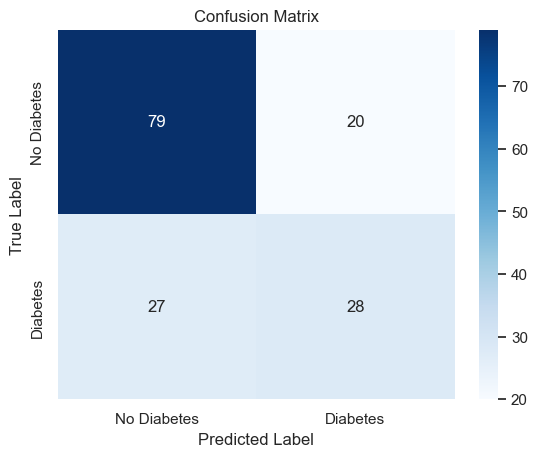

Accuracy for k = 614: 0.64


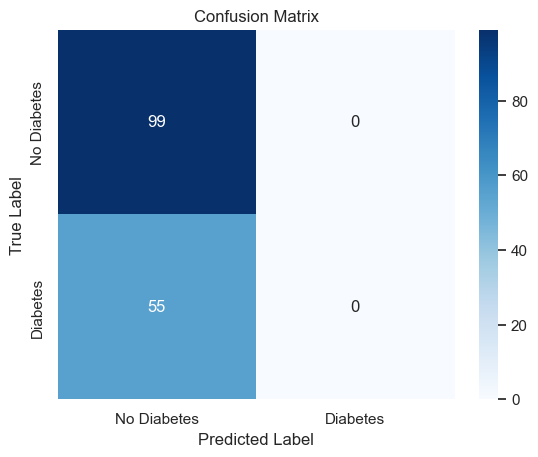

In [20]:
# Perform a k-NN on the given dataset and plot the confusion matrix
# compute number of samples
n = len(trainy)
print(n)
for k in [1, n]:
    #### START YOUR SOLUTION HERE ####
    # Fit a kNN classifier
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(trainX, trainy)

    # Compute the predictions on the test data using the trained model
    y_pred = model.predict(testX)

    # Compute accuracy
    accuracy = accuracy_score(testy, y_pred)
    print(f"Accuracy for k = {k}: {accuracy:.2f}")

    # Compute the confusion matrix
    cm = confusion_matrix(testy, y_pred)

    # Plot the confusion matrix using a heatmap
    sns.heatmap(cm, annot=True, xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    plt.show()
    
    #### END YOUR SOLUTION HERE ####